<h3>Импорты</h3>

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from glob import glob
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

import torch
import random
import segmentation_models_pytorch as smp
from segmentation_models_pytorch import utils
import albumentations as albu

c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<h3>Сиды</h3>

In [2]:
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

<h3>Константы</h3>

In [3]:
DATASET_NAME = "camvid-dataset"

X_TRAIN_DIR = f"{DATASET_NAME}/Train"
Y_TRAIN_DIR = f"{DATASET_NAME}/Trainannot"

X_VALID_DIR = f"{DATASET_NAME}/Validation"
Y_VALID_DIR = f"{DATASET_NAME}/Validationannot"

LABEL_COLORS_FILE = f"{DATASET_NAME}/label_colors.txt"

In [4]:
CLASSES = ['background', 'bodywork', 'disks', 'glass']

ENCODER = 'resnet18'
ENCODER_WEIGHTS = 'imagenet'
ACTIVATION = 'softmax2d'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EPOCHS = 60
BATCH_SIZE = 32

INIT_LR = 0.0001
LR_DECREASE_STEP = 15 # уменьшение шага каждой 15 эпохи
LR_DECREASE_COEF = 2 # во сколько раз уменьшаем шаг обучения

INFER_WIDTH = 256
INFER_HEIGHT = 256

loss = utils.losses.DiceLoss()

In [5]:
color_map = np.array([
        [0, 0, 0], # 0: background - черный
        [255, 0, 0], # 1: bodywork - красный
        [0, 255, 0], # 2: disks - зеленый
        [0, 0, 255], # 3: glass - синий        
    ], dtype=np.uint8)

<h3>Класс датасета</h3>

In [6]:
class SegmentationElCar(Dataset):
    def __init__(self, img_paths, mask_paths, augmentations):
        self.img_paths = sorted(glob(f"{img_paths}/*"))
        self.mask_paths = sorted(glob(f"{mask_paths}/*"))
        self.samples = list(zip(self.img_paths, self.mask_paths)) # (изображение, маска)

        self.colors = self._get_colors(LABEL_COLORS_FILE)

        self.augmentations = augmentations
    
    def __getitem__(self, index):
        image = cv.imread(self.samples[index][0]) # (B, G, R)
        image = cv.cvtColor(image, cv.COLOR_BGR2RGB) # (R, G, B)

        mask = cv.imread(self.samples[index][1])
        mask = cv.cvtColor(mask, cv.COLOR_BGR2RGB)

        masks = []
        for cls in CLASSES:
            color = self.colors[cls] # получаем цвет (R, G, B)
            m = cv.inRange(mask, color, color) # 0 - если цвет не совпал с color, 255 - если совпал
            masks.append((m > 0).astype(np.float32)) # приводим к 0/1

        mask = np.stack(masks, axis=-1).astype(np.float32) # (H, W, C)

        if self.augmentations:
            pair = self.augmentations(image=image, mask=mask)
            image, mask = pair["image"], pair["mask"] # (H, W, C)
        
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255 # превращаем в тензор, размерность (C, H, W), нормализация [0, 1]
        mask = torch.from_numpy(mask).permute(2, 0, 1).float()

        return image, mask

    def _get_colors(self, label_colors_dir):
        """Функция формирования словаря цветов"""
        main_colors = {}
        with open(label_colors_dir) as file:
            for line in file:
                R, G, B, label = line.strip().split()
                main_colors[label] = np.array([int(R), int(G), int(B)], dtype=np.uint8) # class: (R, G, B)

        keyorder = CLASSES
        all_colors = {}

        for k in keyorder: # извлекаем класс
            if k in main_colors:
                all_colors[k] = main_colors[k]
            elif k == "background":
                all_colors[k] = np.array([0, 0, 0], dtype=np.uint8)
            else:
                raise ValueError(f"Ненайденная метка {k} в словаре цветов {main_colors}")
            
        return all_colors

    def __len__(self):
        return len(self.samples)

<h3>Аугментации</h3>

In [7]:
def process_train_augmentation():
    """Функция выполнения аугментаций для изображения и маски"""
    return albu.Compose([
        albu.Resize(height=INFER_HEIGHT, width=INFER_WIDTH),
        albu.HorizontalFlip(p=0.5),
        albu.ShiftScaleRotate(shift_limit=0.1, # сдвиг до 10%
            scale_limit=0.2, # масштаб (+-20%)
            rotate_limit=10, # поворот (+-10%)
            p=0.7),

        # квадраты на картинке
        albu.CoarseDropout( 
            max_holes=4, # количество квадратов
            max_height=45, max_width=45, p=0.5
        ),

        albu.RandomBrightnessContrast(
            brightness_limit=0.2, # яркость
            contrast_limit=0.2, p=0.7
        ),
    ])

def process_valid_augmentation():
    return albu.Compose([
        albu.Resize(height=INFER_HEIGHT, width=INFER_WIDTH),
    ])

<h3>Визуализация</h3>

In [8]:
images = sorted(glob(f"{X_TRAIN_DIR}/*"))
masks = sorted(glob(f"{Y_TRAIN_DIR}/*"))

random_idx = random.randint(0, len(images)-1)

random_img = images[random_idx]
random_mask = masks[random_idx]

c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\User\AppData\Local\Temp\ipykernel_12472\115024635.py:12: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  albu.CoarseDropout(


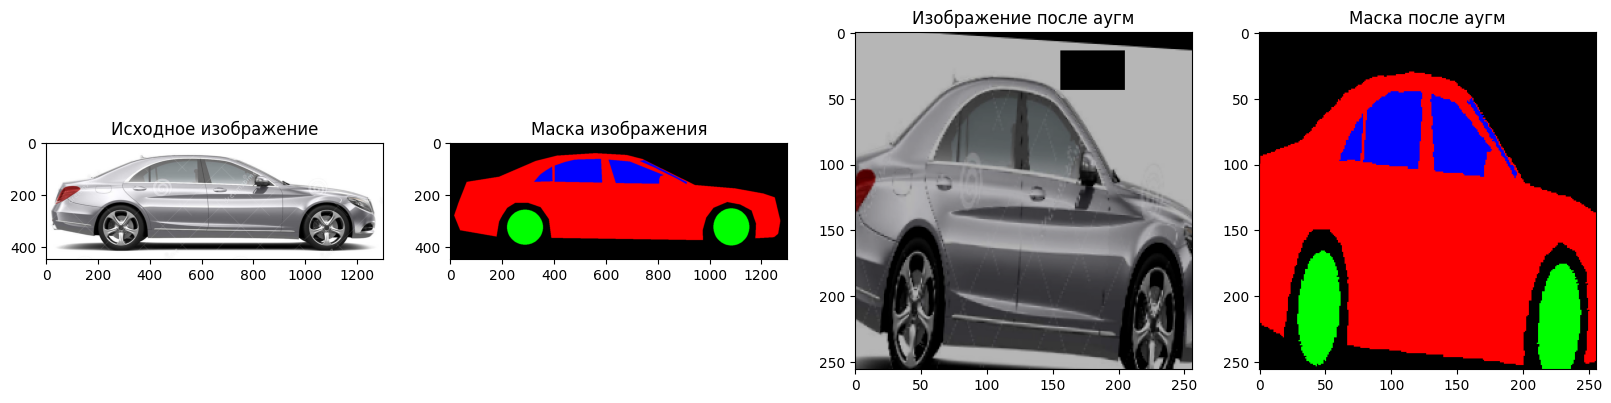

In [9]:
def vizualize_augmentation(augmentations, img, mask):
    """Визуализация аугментаций, применяемых к изображению и маске"""
    img = cv.cvtColor(cv.imread(img), cv.COLOR_BGR2RGB)
    mask = cv.cvtColor(cv.imread(mask), cv.COLOR_BGR2RGB)

    pair = augmentations(image=img, mask=mask)
    img_augm, mask_augm = pair["image"], pair["mask"]

    _, axes = plt.subplots(1, 4, figsize=(20, 8))
    axes[0].imshow(img)
    axes[0].set_title("Исходное изображение")
    axes[1].imshow(mask)
    axes[1].set_title("Маска изображения")
    axes[2].imshow(img_augm)
    axes[2].set_title("Изображение после аугм")
    axes[3].imshow(mask_augm)
    axes[3].set_title("Маска после аугм")
    plt.show()
    
vizualize_augmentation(process_train_augmentation(), random_img, random_mask)

<h3>Инициализация модели</h3>

In [10]:
model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    classes=len(CLASSES),
    activation=ACTIVATION
)

<h3>Создание датасетов</h3>

In [11]:
# извлечение 1 фотографии
train_dataset = SegmentationElCar(
    X_TRAIN_DIR, 
    Y_TRAIN_DIR, 
    augmentations=process_train_augmentation(), 
)

valid_dataset = SegmentationElCar(
    X_VALID_DIR, 
    Y_VALID_DIR, 
    augmentations=process_valid_augmentation(), 
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False)

C:\Users\User\AppData\Local\Temp\ipykernel_12472\115024635.py:12: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  albu.CoarseDropout(


<h3>Настройка метрик и оптимизатора</h3>

In [12]:
metrics = [
    utils.metrics.Fscore(),
    utils.metrics.IoU()
]

optimizer = torch.optim.Adam([ 
    dict(params=model.parameters(), lr=INIT_LR),
])

<h3>Создание эпох обучения/валидации</h3>

In [13]:
train_epoch = utils.train.TrainEpoch(model, loss=loss, metrics=metrics, optimizer=optimizer, device=DEVICE, verbose=True)
valid_epoch = utils.train.ValidEpoch(model, loss=loss, metrics=metrics, device=DEVICE, verbose=True)

<h3>Цикл обучения</h3>

In [14]:
max_score = 0

loss_logs = {"train": [], "val": []}
IoU_logs = {"train": [], "val": []}

for i in range(0, EPOCHS):
    print(f"Эпоха: {i}")
    train_logs = train_epoch.run(train_loader)
    train_loss, _, train_metric_IOU = train_logs.values()
    
    loss_logs["train"].append(train_loss)
    IoU_logs["train"].append(train_metric_IOU)

    valid_logs = valid_epoch.run(valid_loader)
    val_loss, _, val_metric_IOU = valid_logs.values()

    loss_logs["val"].append(val_loss)
    IoU_logs["val"].append(val_metric_IOU)

    print(f"Train: loss - {train_loss:.3f}, IoU - {train_metric_IOU:.3f}")
    print(f"Valid: loss - {val_loss:.3f}, IoU - {val_metric_IOU:.3f}")
    
    if max_score < val_metric_IOU:
        max_score = val_metric_IOU
        torch.save(model, 'models/best_model_new.pth')
        print('Лучшая модель сохранена')

    if i > 0 and i % LR_DECREASE_STEP == 0:
        optimizer.param_groups[0]['lr'] /= LR_DECREASE_COEF

Эпоха: 0
valid: 100%|██████████| 1/1 [00:00<00:00,  1.77it/s, dice_loss - 0.7, fscore - 0.2302, iou_score - 0.1301]
Train: loss - 0.653, IoU - 0.204
Valid: loss - 0.700, IoU - 0.130
Лучшая модель сохранена
Эпоха: 1
valid: 100%|██████████| 1/1 [00:00<00:00,  1.82it/s, dice_loss - 0.3999, fscore - 0.7511, iou_score - 0.6013]
Train: loss - 0.518, IoU - 0.439
Valid: loss - 0.400, IoU - 0.601
Лучшая модель сохранена
Эпоха: 2
valid: 100%|██████████| 1/1 [00:00<00:00,  1.80it/s, dice_loss - 0.31, fscore - 0.8559, iou_score - 0.7481]
Train: loss - 0.422, IoU - 0.614
Valid: loss - 0.310, IoU - 0.748
Лучшая модель сохранена
Эпоха: 3
valid: 100%|██████████| 1/1 [00:00<00:00,  1.85it/s, dice_loss - 0.2822, fscore - 0.8848, iou_score - 0.7934]
Train: loss - 0.370, IoU - 0.674
Valid: loss - 0.282, IoU - 0.793
Лучшая модель сохранена
Эпоха: 4
valid: 100%|██████████| 1/1 [00:00<00:00,  1.95it/s, dice_loss - 0.2507, fscore - 0.9056, iou_score - 0.8275]
Train: loss - 0.324, IoU - 0.721
Valid: loss - 0.2

<h3>Визуализауия метрик</h3>

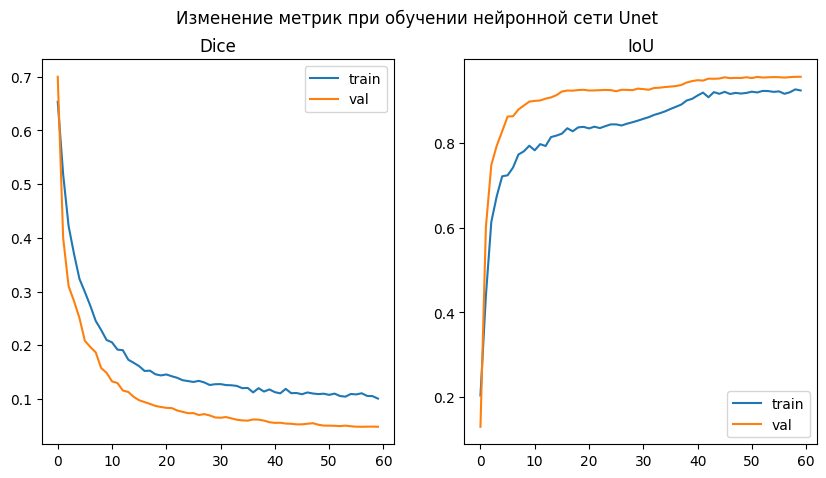

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
fig.suptitle("Изменение метрик при обучении нейронной сети Unet")

axes[0].plot(loss_logs['train'], label="train")
axes[0].plot(loss_logs['val'], label="val")
axes[0].set_title('Dice')

axes[1].plot(IoU_logs['train'], label="train")
axes[1].plot(IoU_logs['val'], label="val")
axes[1].set_title('IoU')

[ax.legend() for ax in axes]

plt.show()

<h3>Анализ модели</h3>

In [16]:
best_model = torch.load('models/best_model_new.pth', weights_only=False)
best_model = best_model.to(DEVICE)

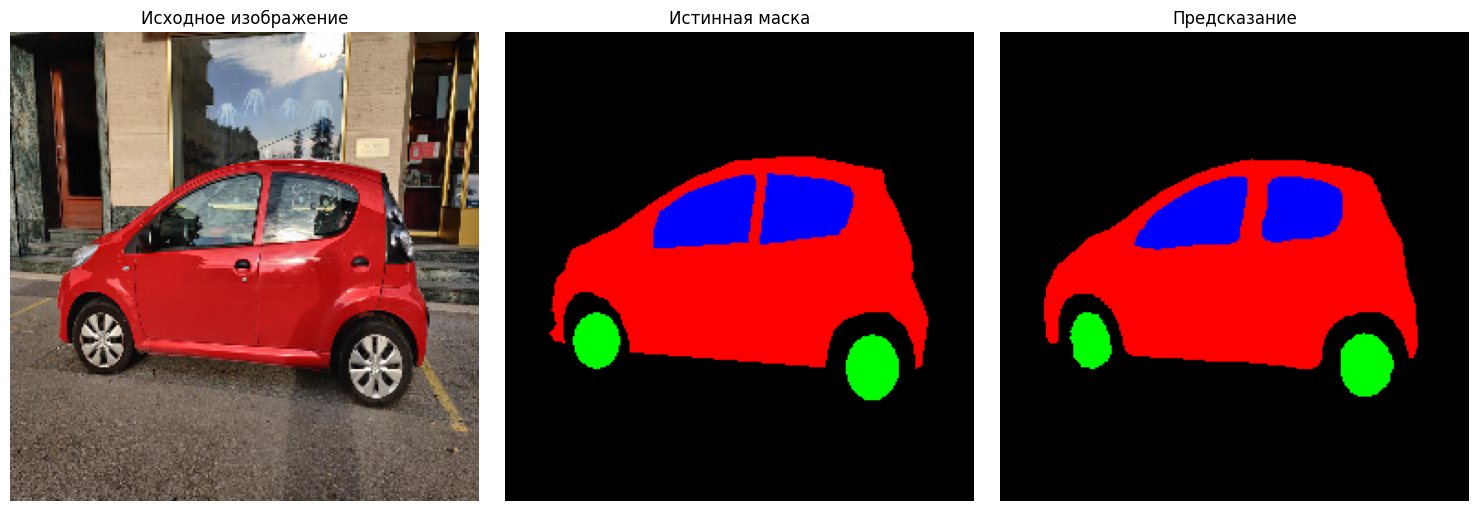

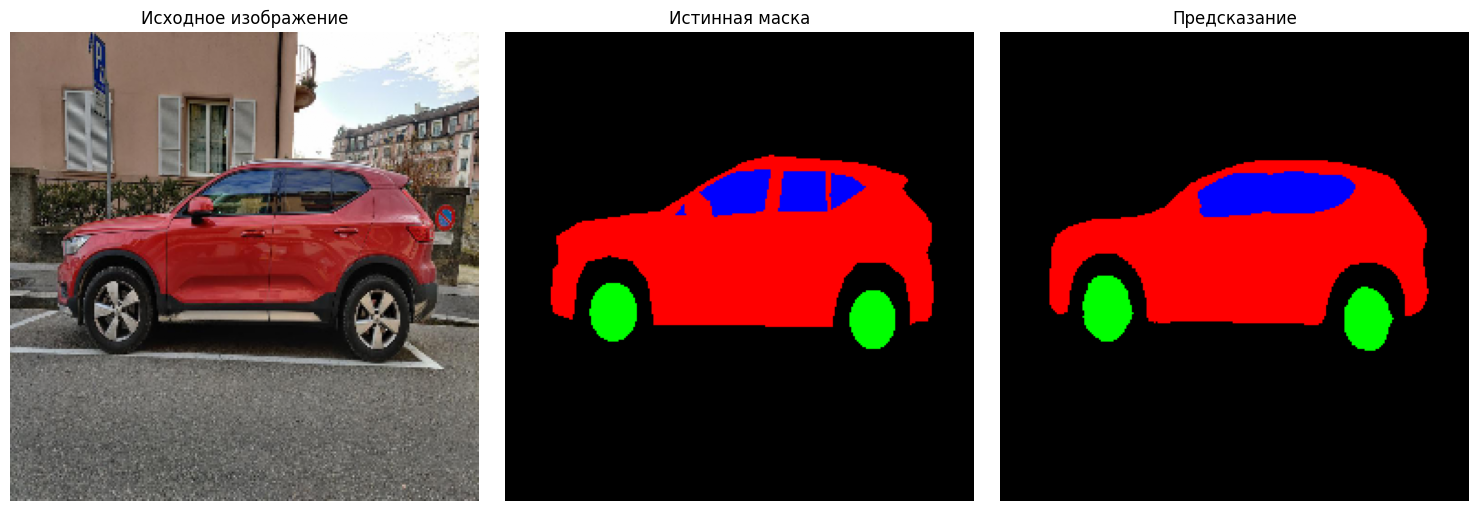

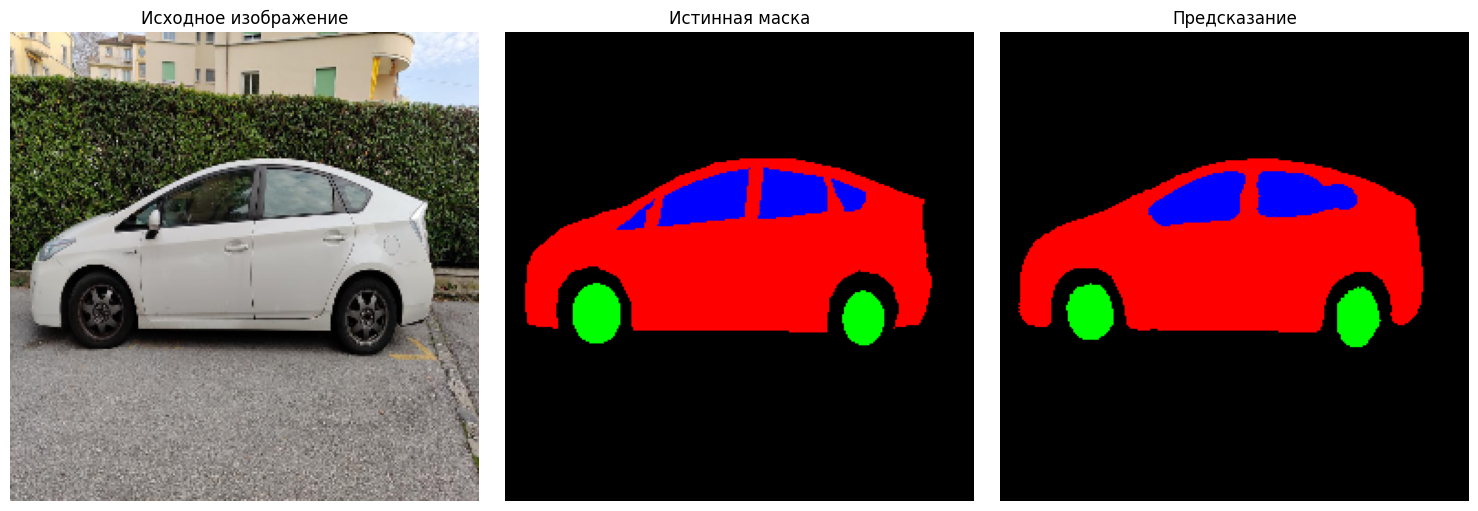

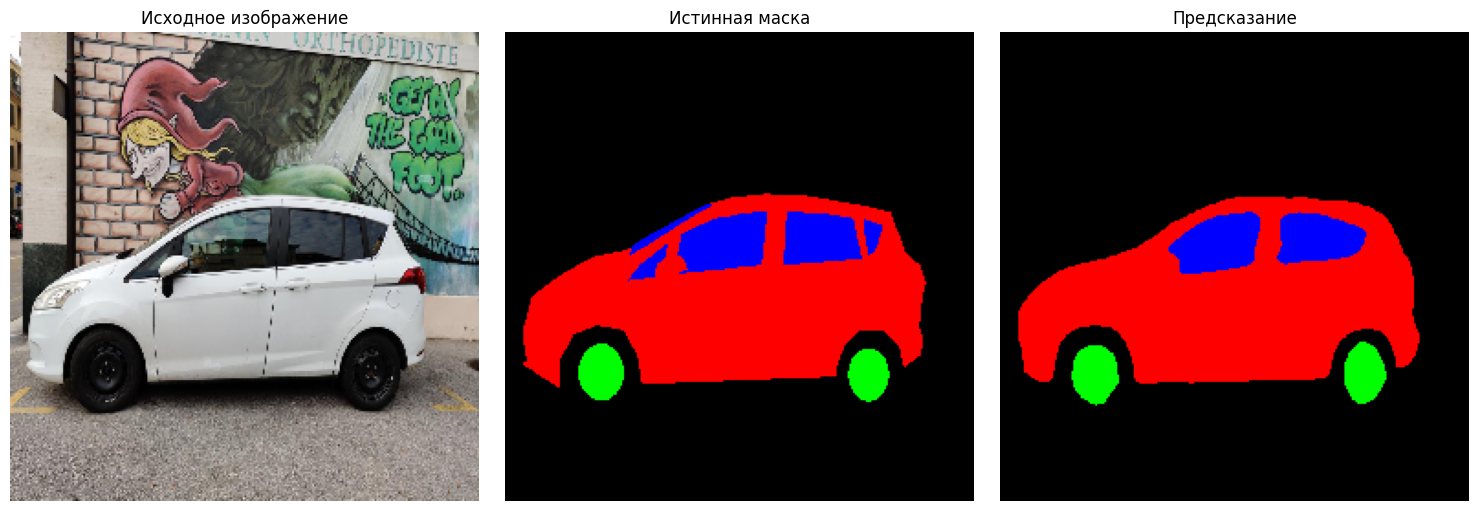

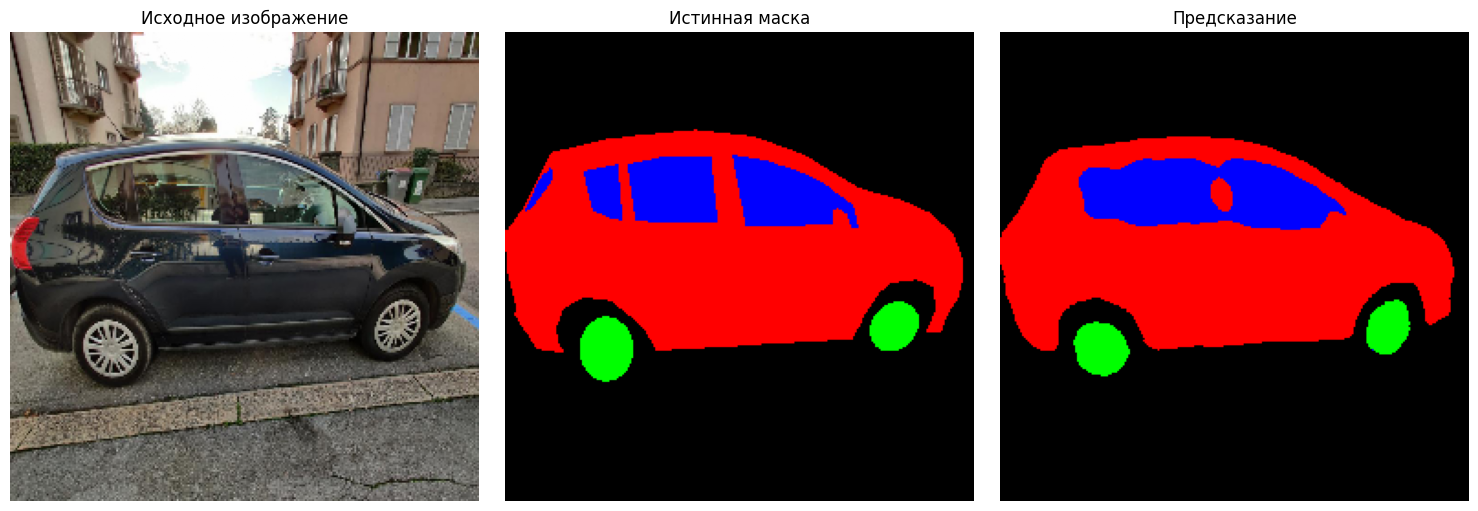

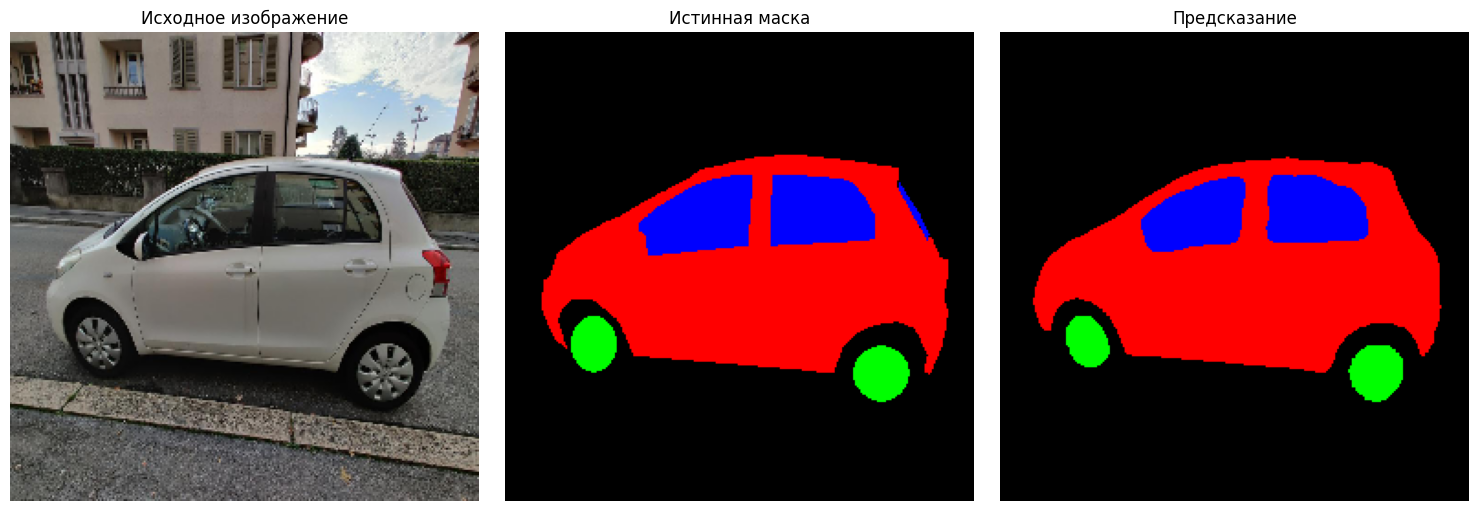

In [17]:
def visualize_from_dataloader(model, dataloader, device, num_samples=1):
    """Визуализация предсказаний на данных из валидационного датасета"""
    model.eval()
    
    images, masks = next(iter(dataloader))
    images = images.to(device)
    
    with torch.no_grad():
        outputs = model(images)
        preds = outputs.argmax(dim=1)
    
    for idx in range(min(num_samples, len(images))):
        img = images[idx].cpu().permute(1, 2, 0).numpy()
        
        # Истинная маска
        true_mask = masks[idx].argmax(dim=0).cpu().numpy()
        true_colored = color_map[true_mask]
        
        # Предсказанная маска
        pred_mask = preds[idx].cpu().numpy()
        pred_colored = color_map[pred_mask]
        
        _, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(img)
        axes[0].set_title('Исходное изображение')
        axes[0].axis('off')
        
        axes[1].imshow(true_colored)
        axes[1].set_title('Истинная маска')
        axes[1].axis('off')
        
        axes[2].imshow(pred_colored)
        axes[2].set_title('Предсказание')
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()

visualize_from_dataloader(best_model, valid_loader, DEVICE, num_samples=6)

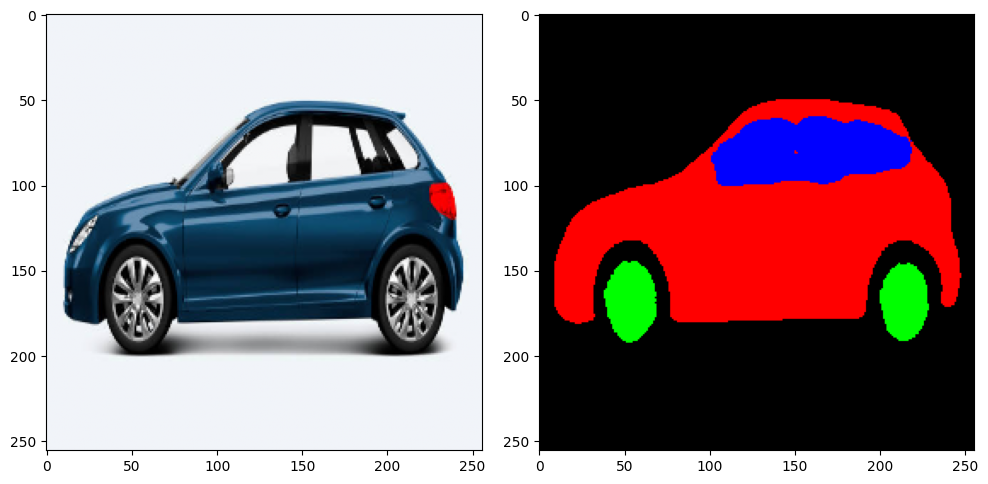

In [18]:
image = cv.imread("test.jpg")
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image = cv.resize(image, (256, 256))
image = image / 255.0
input_tensor = torch.from_numpy(image).permute(2, 0, 1).float().unsqueeze(0).to(DEVICE)

best_model.eval()
with torch.no_grad():
    pred = best_model(input_tensor).argmax(dim=1).squeeze(0).cpu().numpy()

pred_colored = color_map[pred]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image)
axes[1].imshow(pred_colored)
plt.tight_layout()
plt.show()